# EVENT LOGS DATA VISUALIZATION DASHBOARD
# =========================================

This notebook provides comprehensive visualization and analysis of application event logs.
The data is loaded from `events.json` and processed to generate insights about application
behavior, errors, and performance metrics.

## PART 1: SETUP AND DATA LOADING
## --------------------------------

### 1.1 Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import json
from datetime import datetime
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set up visualization styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [15, 8]
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("✅ Libraries imported successfully")


✅ Libraries imported successfully


### 1.2 Define Data Loading Functions

In [2]:
def load_events_data(file_path='Agent-sdk_v2/events.json'):
    """
    Load events data from JSON file
    """
    try:
        with open(file_path, 'r') as file:
            data = json.load(file)
        print(f"✅ Successfully loaded data from {file_path}")
        return data
    except FileNotFoundError:
        print(f"❌ File {file_path} not found!")
        return None
    except json.JSONDecodeError:
        print(f"❌ Invalid JSON format in {file_path}")
        return None

def flatten_events(data):
    """
    Flatten nested event structure into a DataFrame
    """
    flattened_events = []
    
    # Handle both single payload and list of payloads
    if isinstance(data, list):
        payloads = data
    else:
        payloads = [data]
    
    total_events = 0
    for payload in payloads:
        try:
            received_at = payload.get('received_at')
            batch_meta = payload.get('payload', {}).get('batch_meta', {})
            
            # Process each event in the batch
            events = payload.get('payload', {}).get('events', [])
            for event_item in events:
                flat_event = {
                    # Basic metadata
                    'received_at': received_at,
                    'environment': batch_meta.get('environment'),
                    'project': batch_meta.get('project'),
                    'event_count': batch_meta.get('event_count'),
                    'schema_version': batch_meta.get('schema_version'),
                    'sdk_version': batch_meta.get('sdk_version'),
                    
                    # Event details
                    'event_type': event_item.get('event', {}).get('type'),
                    'category': event_item.get('event', {}).get('category'),
                    'severity': event_item.get('event', {}).get('severity'),
                    'status': event_item.get('event', {}).get('status'),
                    'timestamp': event_item.get('meta', {}).get('timestamp'),
                    
                    # Identity info
                    'hostname': event_item.get('identity', {}).get('hostname'),
                    'os': event_item.get('identity', {}).get('os'),
                    'os_version': event_item.get('identity', {}).get('os_version'),
                    'python_version': event_item.get('identity', {}).get('python_version'),
                    'region': event_item.get('identity', {}).get('region'),
                    'app_version': event_item.get('identity', {}).get('app_version'),
                    'instance_id': event_item.get('identity', {}).get('instance_id'),
                    'process_id': event_item.get('identity', {}).get('process_id'),
                    
                    # Trace info
                    'trace_id': event_item.get('meta', {}).get('trace_id'),
                    
                    # Data fields (will vary by event type)
                    'message': None,
                    'file': None,
                    'line': None,
                    'logger_name': None,
                    'level': None,
                    'method': None,
                    'path': None,
                    'status_code': None,
                    'duration_ms': None
                }
                
                # Extract data fields based on event type
                event_data = event_item.get('event', {}).get('data', {})
                event_metrics = event_item.get('event', {}).get('metrics', {})
                
                if flat_event['event_type'] == 'LOG':
                    flat_event['message'] = event_data.get('message')
                    flat_event['file'] = event_data.get('file')
                    flat_event['line'] = event_data.get('line')
                    flat_event['logger_name'] = event_data.get('logger_name')
                    flat_event['level'] = event_data.get('level')
                elif flat_event['event_type'] == 'INCOMING_REQUEST':
                    flat_event['method'] = event_data.get('method')
                    flat_event['path'] = event_data.get('path')
                    flat_event['status_code'] = event_data.get('status_code')
                    flat_event['duration_ms'] = event_metrics.get('duration_ms')
                
                # Convert timestamp to datetime
                if flat_event['timestamp']:
                    try:
                        flat_event['timestamp'] = pd.to_datetime(flat_event['timestamp'])
                    except:
                        pass
                
                flattened_events.append(flat_event)
                total_events += 1
                
        except Exception as e:
            print(f"⚠️ Warning: Error processing payload: {e}")
            continue
    
    print(f"✅ Flattened {total_events} events successfully")
    return pd.DataFrame(flattened_events)


### 1.3 Load and Prepare Data

In [7]:
# Load the data
print("📂 Loading events.json...")
data = load_events_data('Agent-sdk_v2/events_new1.json')

if data is not None:
    df = flatten_events(data)
    
    # Add time-based columns for analysis
    if not df.empty and 'timestamp' in df.columns:
        df['hour'] = df['timestamp'].dt.hour
        df['date'] = df['timestamp'].dt.date
        df['day_of_week'] = df['timestamp'].dt.day_name()
        df['month'] = df['timestamp'].dt.month
        df['week'] = df['timestamp'].dt.isocalendar().week
    
    print(f"\n📊 Dataset Shape: {df.shape}")
    print(f"📊 Total Events: {len(df)}")
    print(f"📊 Date Range: {df['timestamp'].min()} to {df['timestamp'].max()}")
else:
    print("❌ Failed to load data. Please check the file path.")
    # Create empty DataFrame as fallback
    df = pd.DataFrame()


📂 Loading events.json...
✅ Successfully loaded data from Agent-sdk_v2/events_new1.json
✅ Flattened 280 events successfully

📊 Dataset Shape: (280, 34)
📊 Total Events: 280
📊 Date Range: 2026-03-26 19:16:26.361383+00:00 to 2026-03-26 19:19:02.079504+00:00


### 1.4 Data Overview

In [8]:
if not df.empty:
    print("🔍 First 5 rows of data:")
    display(df.head())
    
    print("\n🔍 Data Info:")
    print("-" * 50)
    print(df.info())
    
    print("\n🔍 Missing Values:")
    print("-" * 50)
    missing_data = df.isnull().sum()[df.isnull().sum() > 0]
    if len(missing_data) > 0:
        print(missing_data)
    else:
        print("No missing values found")
    
    print("\n🔍 Basic Statistics:")
    print("-" * 50)
    print(df.describe(include='all').T)
else:
    print("No data available for analysis")


🔍 First 5 rows of data:


,received_at,environment,project,event_count,schema_version,sdk_version,event_type,category,severity,status,...,level,method,path,status_code,duration_ms,hour,date,day_of_week,month,week
0,2026-03-26T19:16:29.271809,production,client-test-app,14,1.0,2.0.0,SPAN,PERFORMANCE,LOW,SUCCESS,...,NaN,NaN,NaN,NaN,NaN,19,2026-03-26,Thursday,3,13
1,2026-03-26T19:16:29.271809,production,client-test-app,14,1.0,2.0.0,INCOMING_REQUEST,APPLICATION,LOW,SUCCESS,...,NaN,GET,/search,200.0,2.182,19,2026-03-26,Thursday,3,13
2,2026-03-26T19:16:29.271809,production,client-test-app,14,1.0,2.0.0,SPAN,PERFORMANCE,LOW,SUCCESS,...,NaN,NaN,NaN,NaN,NaN,19,2026-03-26,Thursday,3,13
3,2026-03-26T19:16:29.271809,production,client-test-app,14,1.0,2.0.0,LOG,APPLICATION,HIGH,FAILURE,...,ERROR,NaN,NaN,NaN,NaN,19,2026-03-26,Thursday,3,13
4,2026-03-26T19:16:29.271809,production,client-test-app,14,1.0,2.0.0,SPAN,PERFORMANCE,LOW,SUCCESS,...,NaN,NaN,NaN,NaN,NaN,19,2026-03-26,Thursday,3,13



🔍 Data Info:
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 34 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   received_at     280 non-null    str                
 1   environment     280 non-null    str                
 2   project         280 non-null    str                
 3   event_count     280 non-null    int64              
 4   schema_version  280 non-null    str                
 5   sdk_version     280 non-null    str                
 6   event_type      280 non-null    str                
 7   category        280 non-null    str                
 8   severity        280 non-null    str                
 9   status          280 non-null    str                
 10  timestamp       280 non-null    datetime64[us, UTC]
 11  hostname        280 non-null    str                
 12  os              280 non-null    str   

## PART 2: EVENT DISTRIBUTION ANALYSIS
## -----------------------------------

### 2.1 Event Type Distribution


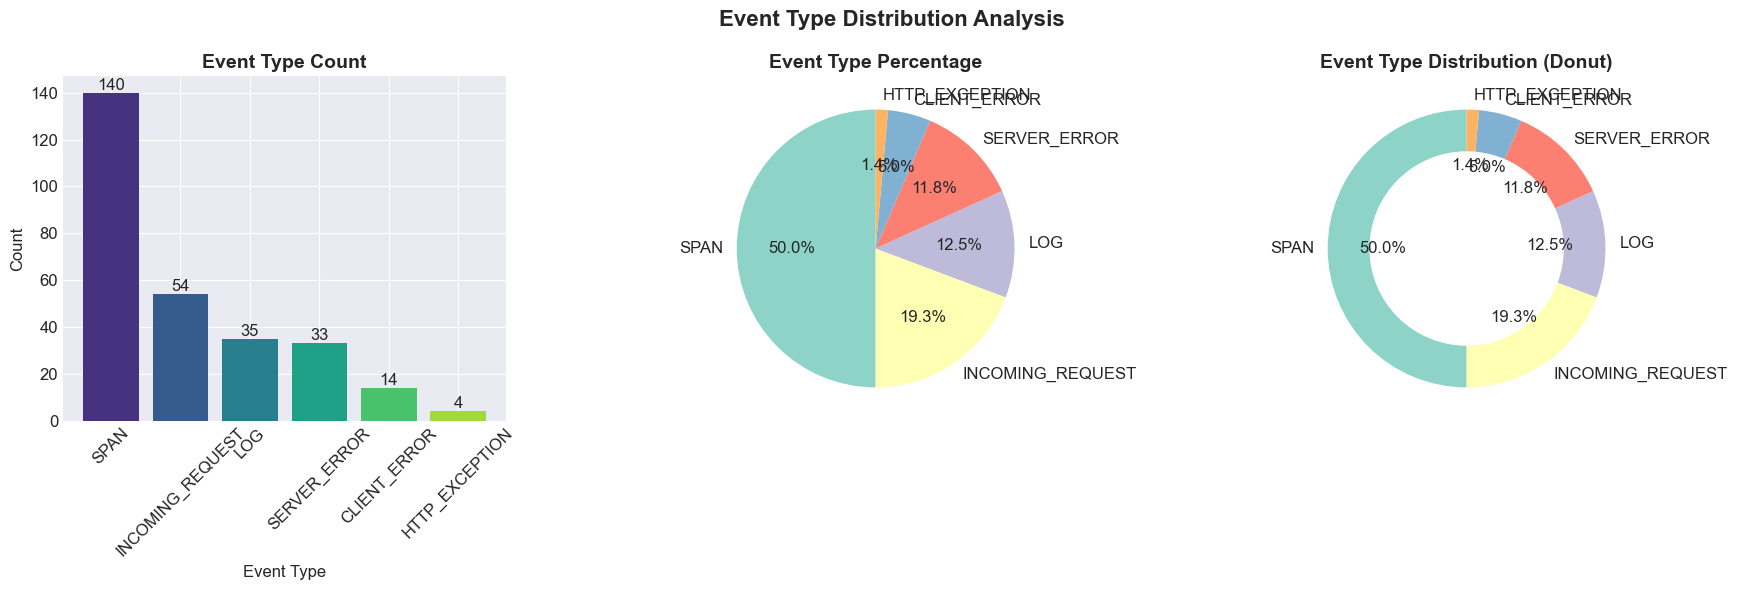


📊 Event Type Summary:
event_type
SPAN                140
INCOMING_REQUEST     54
LOG                  35
SERVER_ERROR         33
CLIENT_ERROR         14
HTTP_EXCEPTION        4


In [9]:

if not df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Event Type Distribution Analysis', fontsize=16, fontweight='bold')
    
    # Bar chart
    ax1 = axes[0]
    event_type_counts = df['event_type'].value_counts()
    bars1 = ax1.bar(event_type_counts.index, event_type_counts.values, 
                    color=sns.color_palette("viridis", len(event_type_counts)))
    ax1.set_title('Event Type Count')
    ax1.set_xlabel('Event Type')
    ax1.set_ylabel('Count')
    ax1.tick_params(axis='x', rotation=45)
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')
    
    # Pie chart
    ax2 = axes[1]
    colors = plt.cm.Set3(range(len(event_type_counts)))
    ax2.pie(event_type_counts.values, labels=event_type_counts.index, 
            autopct='%1.1f%%', colors=colors, startangle=90)
    ax2.set_title('Event Type Percentage')
    ax2.axis('equal')
    
    # Donut chart (alternative)
    ax3 = axes[2]
    wedges, texts, autotexts = ax3.pie(event_type_counts.values, 
                                        labels=event_type_counts.index,
                                        autopct='%1.1f%%', 
                                        colors=colors,
                                        startangle=90,
                                        wedgeprops=dict(width=0.3))
    ax3.set_title('Event Type Distribution (Donut)')
    ax3.axis('equal')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n📊 Event Type Summary:")
    print(event_type_counts.to_string())


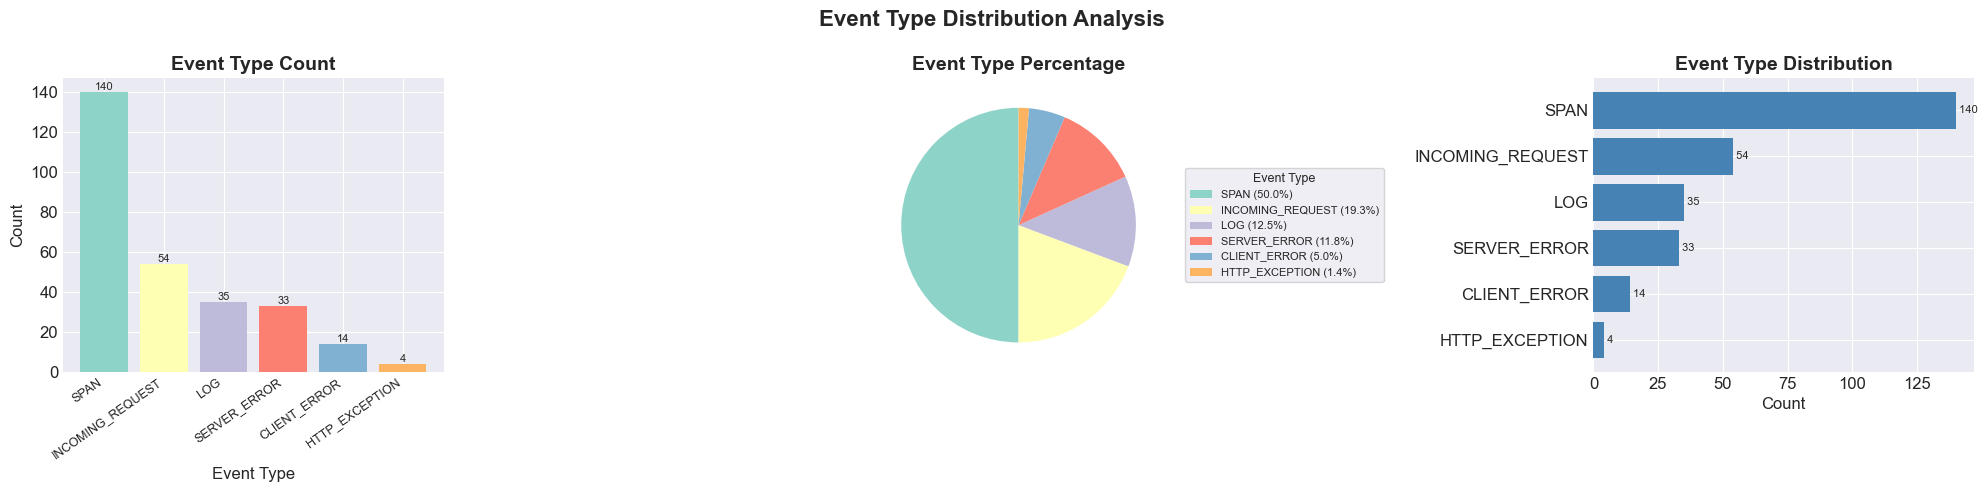

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Event Type Distribution Analysis', fontsize=16, fontweight='bold')

event_counts = df['event_type'].value_counts()
colors = plt.cm.Set3(range(len(event_counts)))

# 🔵 1. Vertical Bar Chart
ax1 = axes[0]
bars1 = ax1.bar(event_counts.index, event_counts.values, color=colors)

ax1.set_title('Event Type Count')
ax1.set_xlabel('Event Type')
ax1.set_ylabel('Count')

ax1.set_xticklabels(event_counts.index, rotation=35, ha='right', fontsize=9)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=8)


# 🔵 2. Pie Chart
ax2 = axes[1]

wedges, _ = ax2.pie(
    event_counts.values,
    colors=colors,
    startangle=90
)

ax2.set_title('Event Type Percentage')

# legend with percentage
total = event_counts.sum()
legend_labels = [
    f"{name} ({count/total*100:.1f}%)"
    for name, count in zip(event_counts.index, event_counts.values)
]

ax2.legend(
    wedges,
    legend_labels,
    title="Event Type",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    fontsize=8,
    title_fontsize=9,
    frameon=True
)


# 🔵 3. Horizontal Bar Chart
ax3 = axes[2]
event_counts_sorted = event_counts.sort_values()

bars3 = ax3.barh(event_counts_sorted.index, event_counts_sorted.values, color='steelblue')

ax3.set_title('Event Type Distribution')
ax3.set_xlabel('Count')

for bar, count in zip(bars3, event_counts_sorted.values):
    ax3.text(count, bar.get_y() + bar.get_height()/2, f' {count:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()


### 2.2 Severity Level Distribution

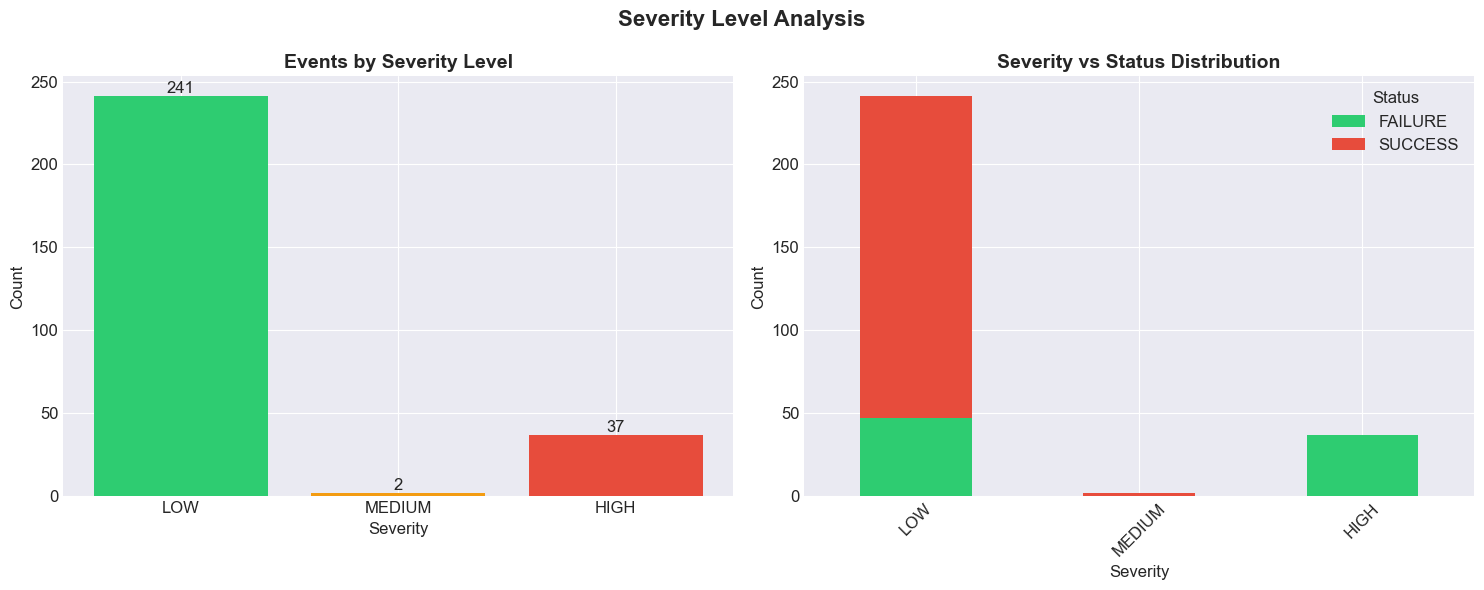


📊 Severity Summary:
severity
LOW       241
MEDIUM      2
HIGH       37

📊 High Severity Events: 37


In [11]:
if not df.empty and 'severity' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Severity Level Analysis', fontsize=16, fontweight='bold')
    
    # Define severity order and colors
    severity_order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
    severity_colors = {'LOW': '#2ecc71', 'MEDIUM': '#f39c12', 
                      'HIGH': '#e74c3c', 'CRITICAL': '#8e44ad'}
    
    # Get severity counts in correct order
    severity_counts = df['severity'].value_counts()
    severity_counts = severity_counts.reindex([s for s in severity_order if s in severity_counts.index])
    
    # Bar chart
    ax1 = axes[0]
    colors = [severity_colors.get(sev, '#3498db') for sev in severity_counts.index]
    bars1 = ax1.bar(severity_counts.index, severity_counts.values, color=colors)
    ax1.set_title('Events by Severity Level')
    ax1.set_xlabel('Severity')
    ax1.set_ylabel('Count')
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')
    
    # Stacked bar chart with status
    ax2 = axes[1]
    severity_status = pd.crosstab(df['severity'], df['status'])
    severity_status = severity_status.reindex([s for s in severity_order if s in severity_status.index])
    severity_status.plot(kind='bar', stacked=True, ax=ax2, color=['#2ecc71', '#e74c3c'])
    ax2.set_title('Severity vs Status Distribution')
    ax2.set_xlabel('Severity')
    ax2.set_ylabel('Count')
    ax2.legend(title='Status')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n📊 Severity Summary:")
    print(severity_counts.to_string())
    print(f"\n📊 High Severity Events: {severity_counts.get('HIGH', 0)}")


### 2.3 Status Distribution

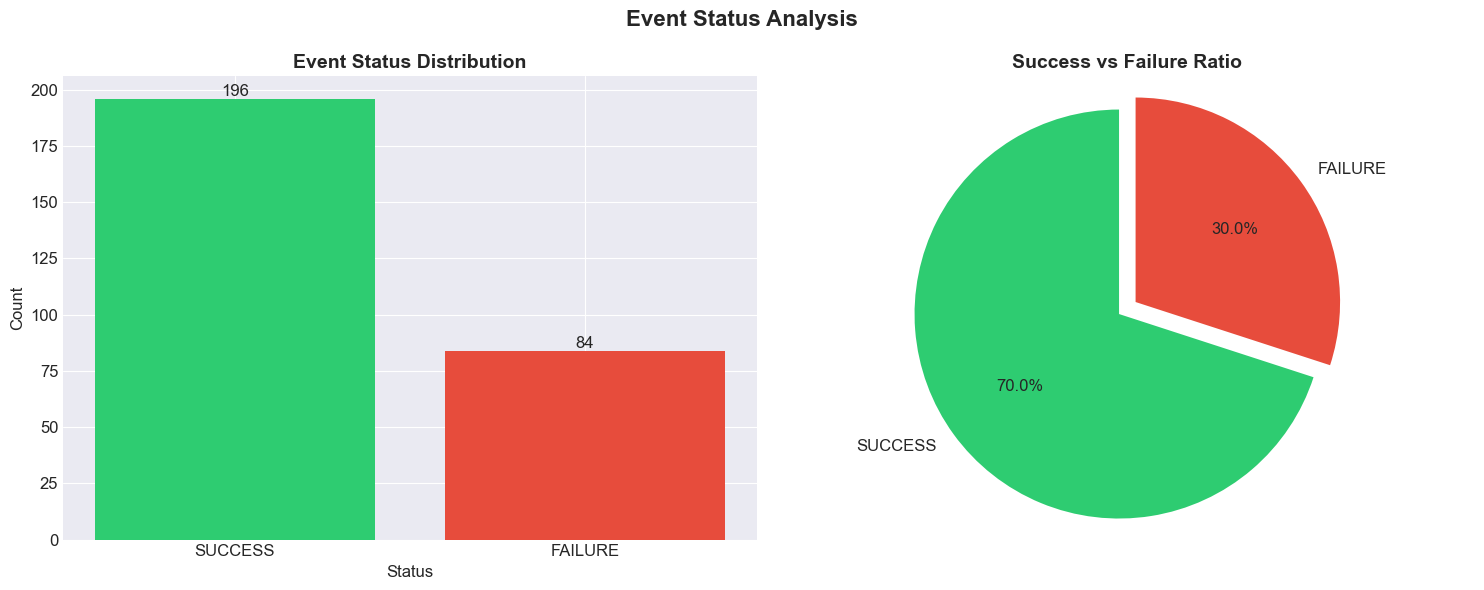


📊 Success Rate: 70.00%


In [12]:

if not df.empty and 'status' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Event Status Analysis', fontsize=16, fontweight='bold')
    
    # Status counts
    status_counts = df['status'].value_counts()
    
    # Bar chart
    ax1 = axes[0]
    colors = ['#2ecc71' if s == 'SUCCESS' else '#e74c3c' for s in status_counts.index]
    bars1 = ax1.bar(status_counts.index, status_counts.values, color=colors)
    ax1.set_title('Event Status Distribution')
    ax1.set_xlabel('Status')
    ax1.set_ylabel('Count')
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')
    
    # Success/Failure ratio
    ax2 = axes[1]
    success_count = status_counts.get('SUCCESS', 0)
    failure_count = status_counts.get('FAILURE', 0)
    
    if success_count + failure_count > 0:
        wedges, texts, autotexts = ax2.pie([success_count, failure_count],
                                           labels=['SUCCESS', 'FAILURE'],
                                           autopct='%1.1f%%',
                                           colors=['#2ecc71', '#e74c3c'],
                                           explode=(0.05, 0.05),
                                           startangle=90)
        ax2.set_title('Success vs Failure Ratio')
        ax2.axis('equal')
    else:
        ax2.text(0.5, 0.5, 'No status data available', ha='center', va='center')
    
    plt.tight_layout()
    plt.show()
    
    # Calculate success rate
    total = len(df)
    success_rate = (status_counts.get('SUCCESS', 0) / total * 100) if total > 0 else 0
    print(f"\n📊 Success Rate: {success_rate:.2f}%")


## PART 3: TIME SERIES ANALYSIS
## ----------------------------

### 3.1 Events Over Time


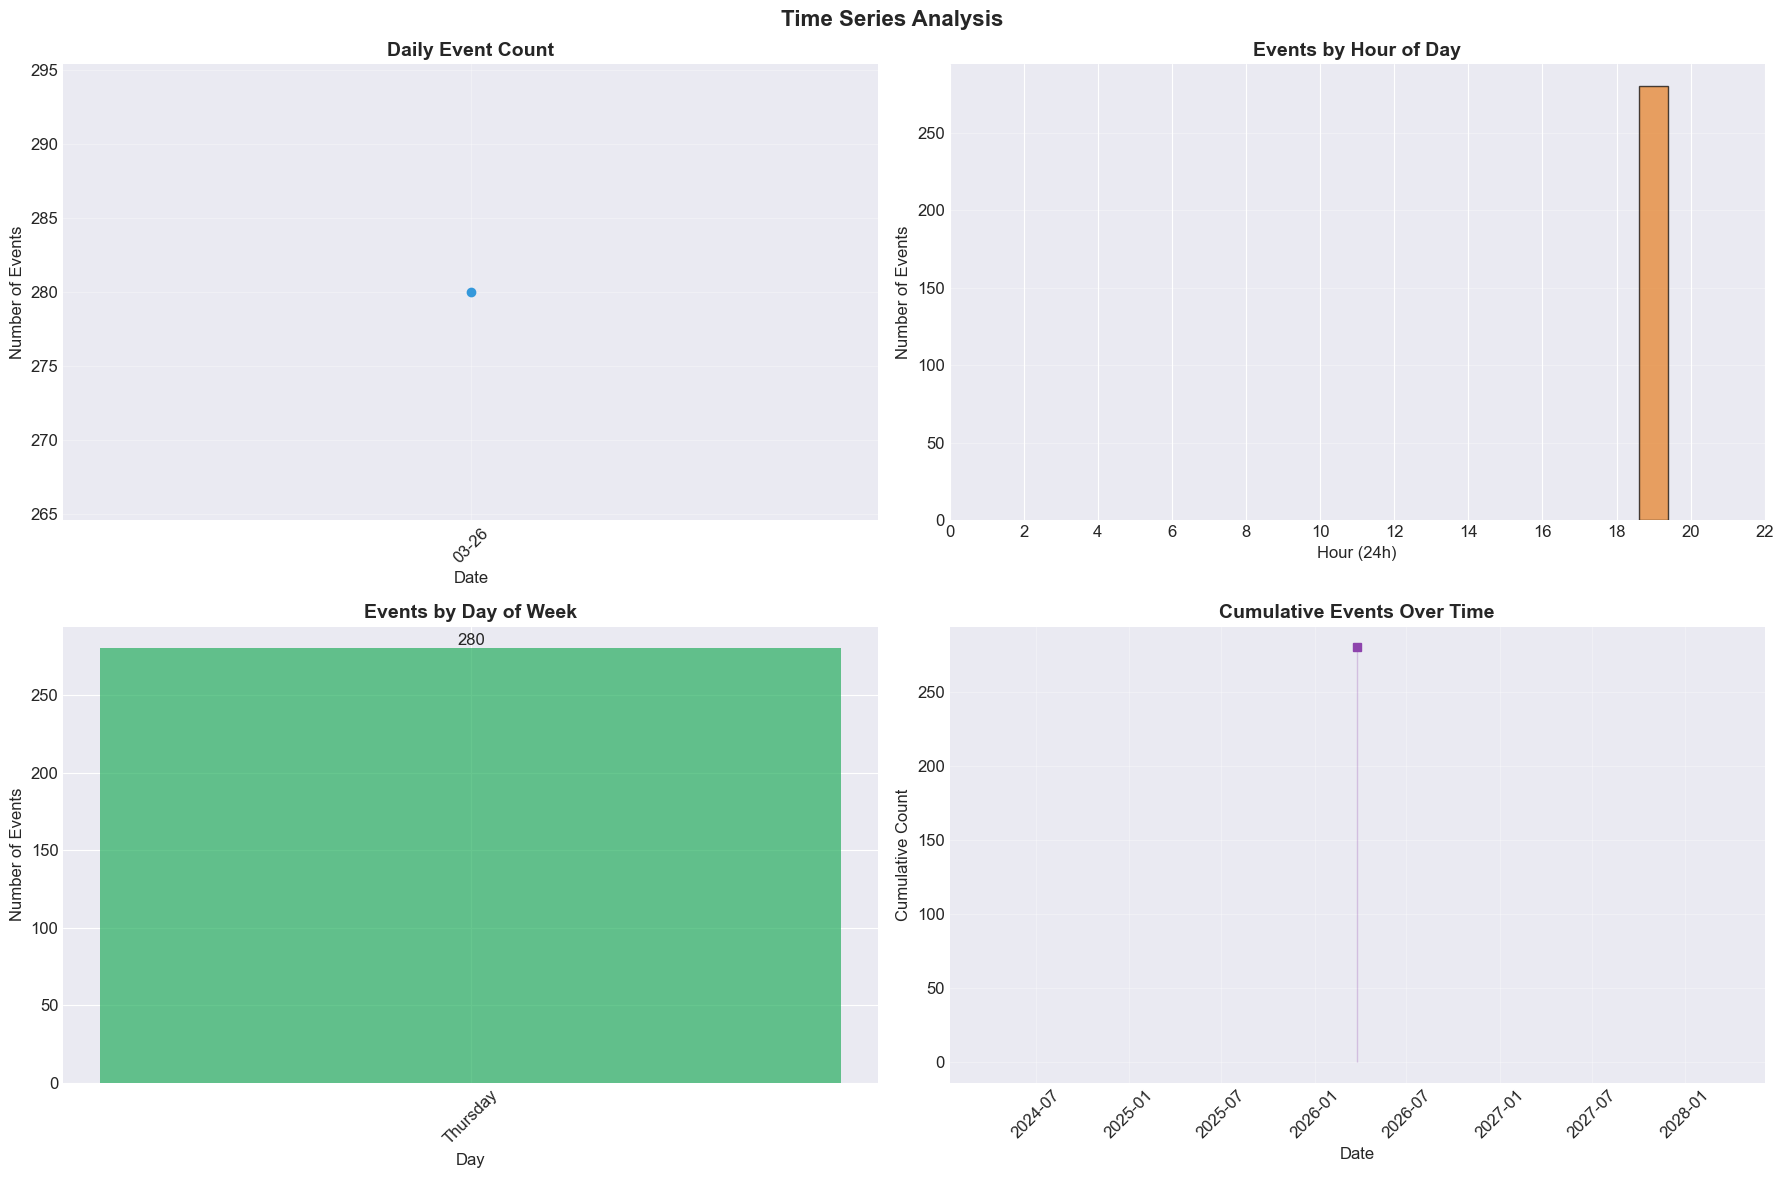


⏰ Peak Activity Times:
   Busiest Hour: 19:00 (280 events)
   Busiest Day: Thursday (280 events)
   Average Daily Events: 280.0


In [13]:
if not df.empty and 'timestamp' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Time Series Analysis', fontsize=16, fontweight='bold')
    
    # 1. Daily events
    ax1 = axes[0, 0]
    daily_events = df.groupby('date').size()
    ax1.plot(range(len(daily_events)), daily_events.values, 
             marker='o', linewidth=2, markersize=6, color='#3498db')
    ax1.set_title('Daily Event Count')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Number of Events')
    ax1.set_xticks(range(0, len(daily_events), max(1, len(daily_events)//10)))
    ax1.set_xticklabels([str(d)[5:] for d in daily_events.index[::max(1, len(daily_events)//10)]], 
                        rotation=45)
    ax1.grid(True, alpha=0.3)
    
    # 2. Hourly pattern
    ax2 = axes[0, 1]
    hourly_events = df.groupby('hour').size()
    ax2.bar(hourly_events.index, hourly_events.values, 
            color='#e67e22', alpha=0.7, edgecolor='black')
    ax2.set_title('Events by Hour of Day')
    ax2.set_xlabel('Hour (24h)')
    ax2.set_ylabel('Number of Events')
    ax2.set_xticks(range(0, 24, 2))
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. Day of week pattern
    ax3 = axes[1, 0]
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_events = df['day_of_week'].value_counts()
    day_events = day_events.reindex([d for d in day_order if d in day_events.index])
    bars3 = ax3.bar(day_events.index, day_events.values, color='#27ae60', alpha=0.7)
    ax3.set_title('Events by Day of Week')
    ax3.set_xlabel('Day')
    ax3.set_ylabel('Number of Events')
    ax3.tick_params(axis='x', rotation=45)
    for bar in bars3:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')
    
    # 4. Cumulative events over time
    ax4 = axes[1, 1]
    daily_cumsum = daily_events.cumsum()
    ax4.fill_between(daily_cumsum.index, daily_cumsum.values, 
                      alpha=0.3, color='#9b59b6')
    ax4.plot(daily_cumsum.index, daily_cumsum.values, 
             marker='s', linewidth=2, color='#8e44ad')
    ax4.set_title('Cumulative Events Over Time')
    ax4.set_xlabel('Date')
    ax4.set_ylabel('Cumulative Count')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print time patterns
    print("\n⏰ Peak Activity Times:")
    print(f"   Busiest Hour: {hourly_events.idxmax()}:00 ({hourly_events.max()} events)")
    print(f"   Busiest Day: {day_events.idxmax()} ({day_events.max()} events)")
    print(f"   Average Daily Events: {daily_events.mean():.1f}")


### 3.2 Severity Trends Over Time

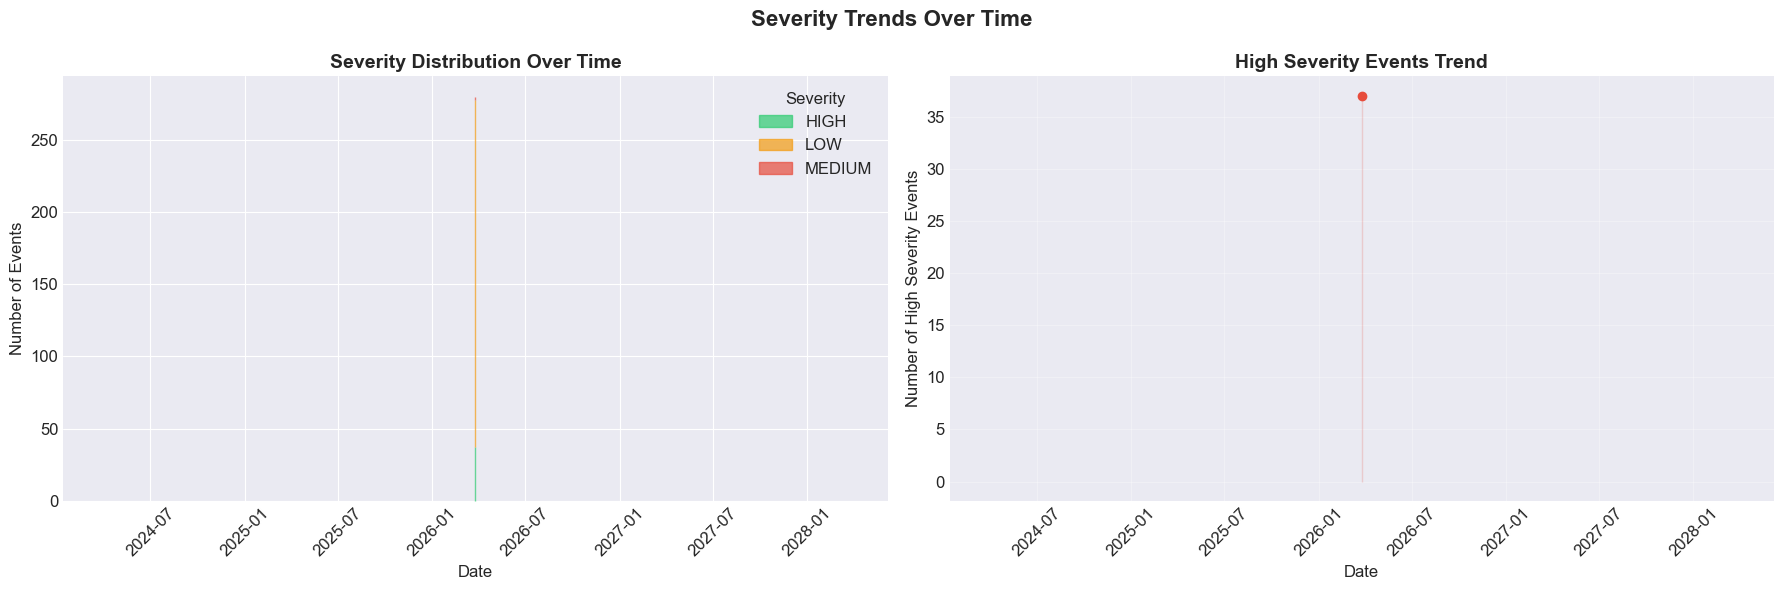

In [14]:
if not df.empty and 'timestamp' in df.columns and 'severity' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('Severity Trends Over Time', fontsize=16, fontweight='bold')
    
    # 1. Stacked area chart
    ax1 = axes[0]
    severity_time = df.groupby(['date', 'severity']).size().unstack(fill_value=0)
    severity_time.plot(kind='area', stacked=True, ax=ax1, alpha=0.7,
                       color=['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad'])
    ax1.set_title('Severity Distribution Over Time')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Number of Events')
    ax1.legend(title='Severity')
    ax1.tick_params(axis='x', rotation=45)
    
    # 2. High severity trend
    ax2 = axes[1]
    if 'HIGH' in severity_time.columns:
        high_severity = severity_time['HIGH']
        ax2.plot(high_severity.index, high_severity.values, 
                 marker='o', linewidth=2, color='#e74c3c', markersize=6)
        ax2.fill_between(high_severity.index, high_severity.values, 
                         alpha=0.2, color='#e74c3c')
        ax2.set_title('High Severity Events Trend')
        ax2.set_xlabel('Date')
        ax2.set_ylabel('Number of High Severity Events')
        ax2.tick_params(axis='x', rotation=45)
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## PART 4: INFRASTRUCTURE ANALYSIS
## -------------------------------

### 4.1 Host Distribution


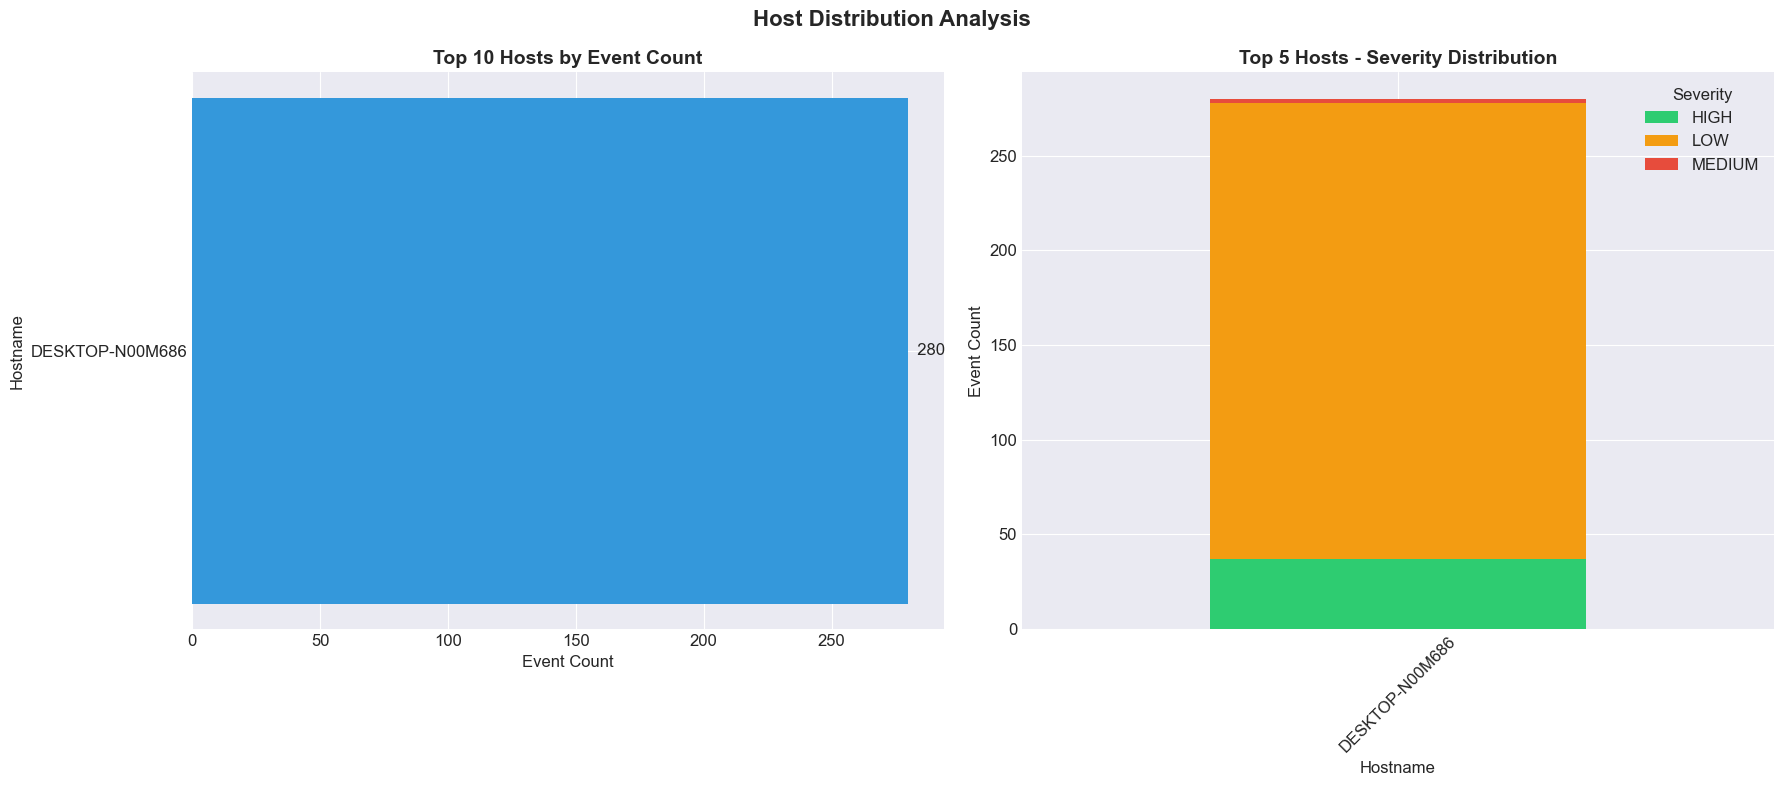


💻 Total Unique Hosts: 1


In [15]:

if not df.empty and 'hostname' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle('Host Distribution Analysis', fontsize=16, fontweight='bold')
    
    # Top 10 hosts
    ax1 = axes[0]
    top_hosts = df['hostname'].value_counts().head(10)
    bars1 = ax1.barh(range(len(top_hosts)), top_hosts.values, color='#3498db')
    ax1.set_title('Top 10 Hosts by Event Count')
    ax1.set_xlabel('Event Count')
    ax1.set_ylabel('Hostname')
    ax1.set_yticks(range(len(top_hosts)))
    ax1.set_yticklabels(top_hosts.index)
    for i, (bar, count) in enumerate(zip(bars1, top_hosts.values)):
        ax1.text(count, i, f'  {count}', va='center')
    
    # Host activity by severity
    ax2 = axes[1]
    host_severity = pd.crosstab(df['hostname'], df['severity'])
    top_hosts_severity = host_severity.loc[top_hosts.index[:5]]
    top_hosts_severity.plot(kind='bar', stacked=True, ax=ax2,
                           color=['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad'])
    ax2.set_title('Top 5 Hosts - Severity Distribution')
    ax2.set_xlabel('Hostname')
    ax2.set_ylabel('Event Count')
    ax2.legend(title='Severity')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n💻 Total Unique Hosts: {df['hostname'].nunique()}")


### 4.2 Operating System Distribution

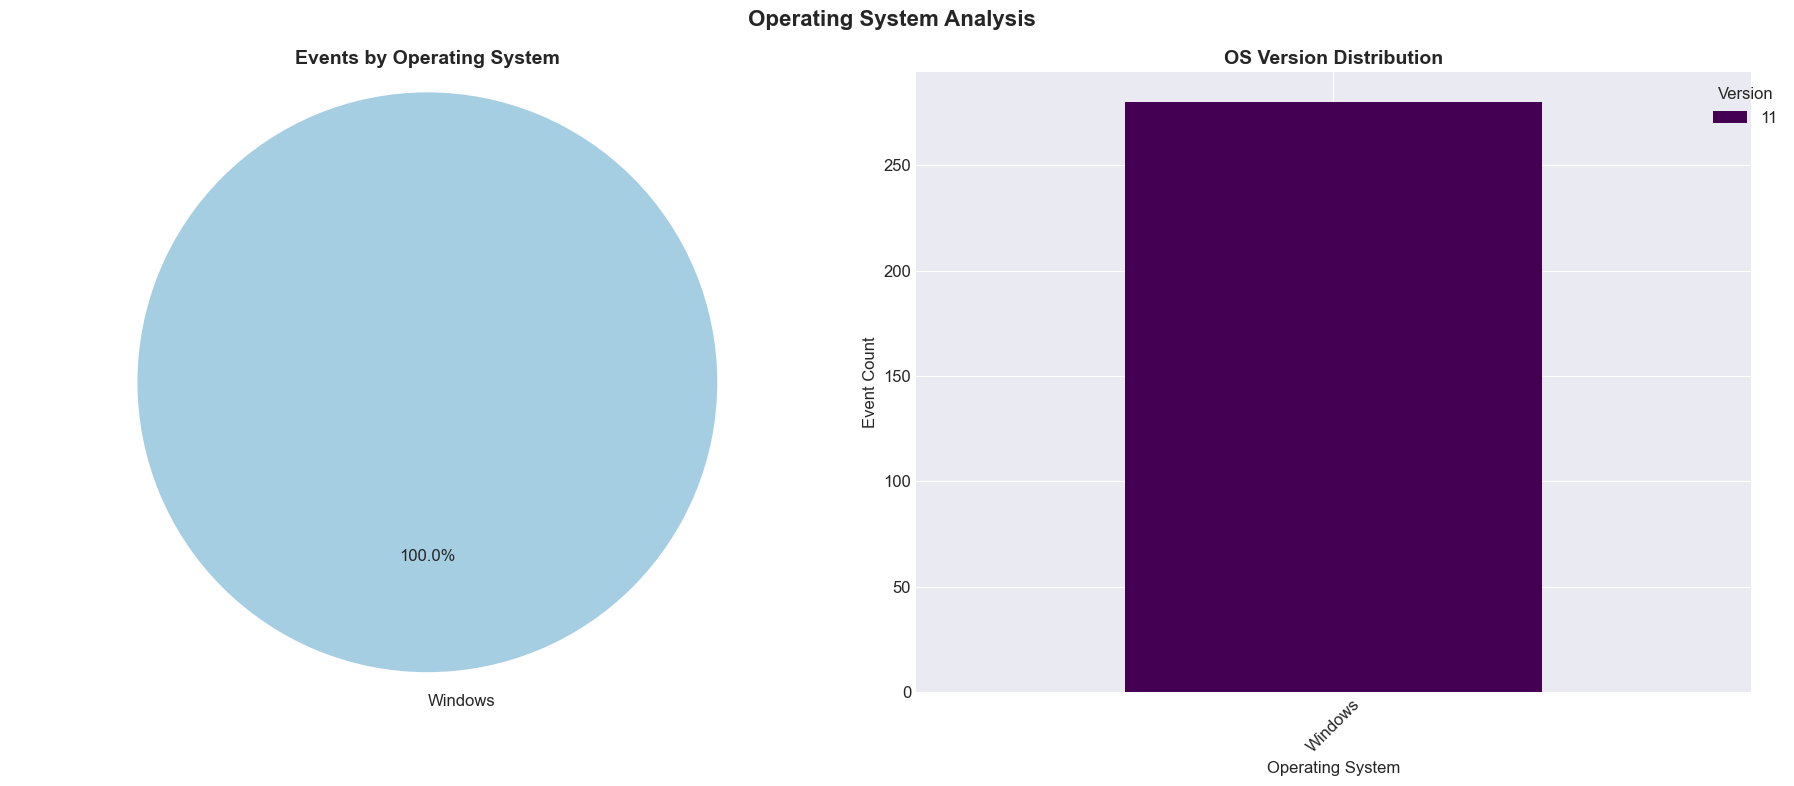

In [16]:
if not df.empty and 'os' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle('Operating System Analysis', fontsize=16, fontweight='bold')
    
    # OS distribution
    ax1 = axes[0]
    os_counts = df['os'].value_counts()
    colors = plt.cm.Paired(range(len(os_counts)))
    wedges, texts, autotexts = ax1.pie(os_counts.values, 
                                        labels=os_counts.index,
                                        autopct='%1.1f%%',
                                        colors=colors,
                                        startangle=90)
    ax1.set_title('Events by Operating System')
    ax1.axis('equal')
    
    # OS by version
    ax2 = axes[1]
    os_version = df.groupby(['os', 'os_version']).size().unstack(fill_value=0)
    os_version.plot(kind='bar', stacked=True, ax=ax2, colormap='viridis')
    ax2.set_title('OS Version Distribution')
    ax2.set_xlabel('Operating System')
    ax2.set_ylabel('Event Count')
    ax2.legend(title='Version', bbox_to_anchor=(1.05, 1))
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()


### 4.3 Python Version Distribution

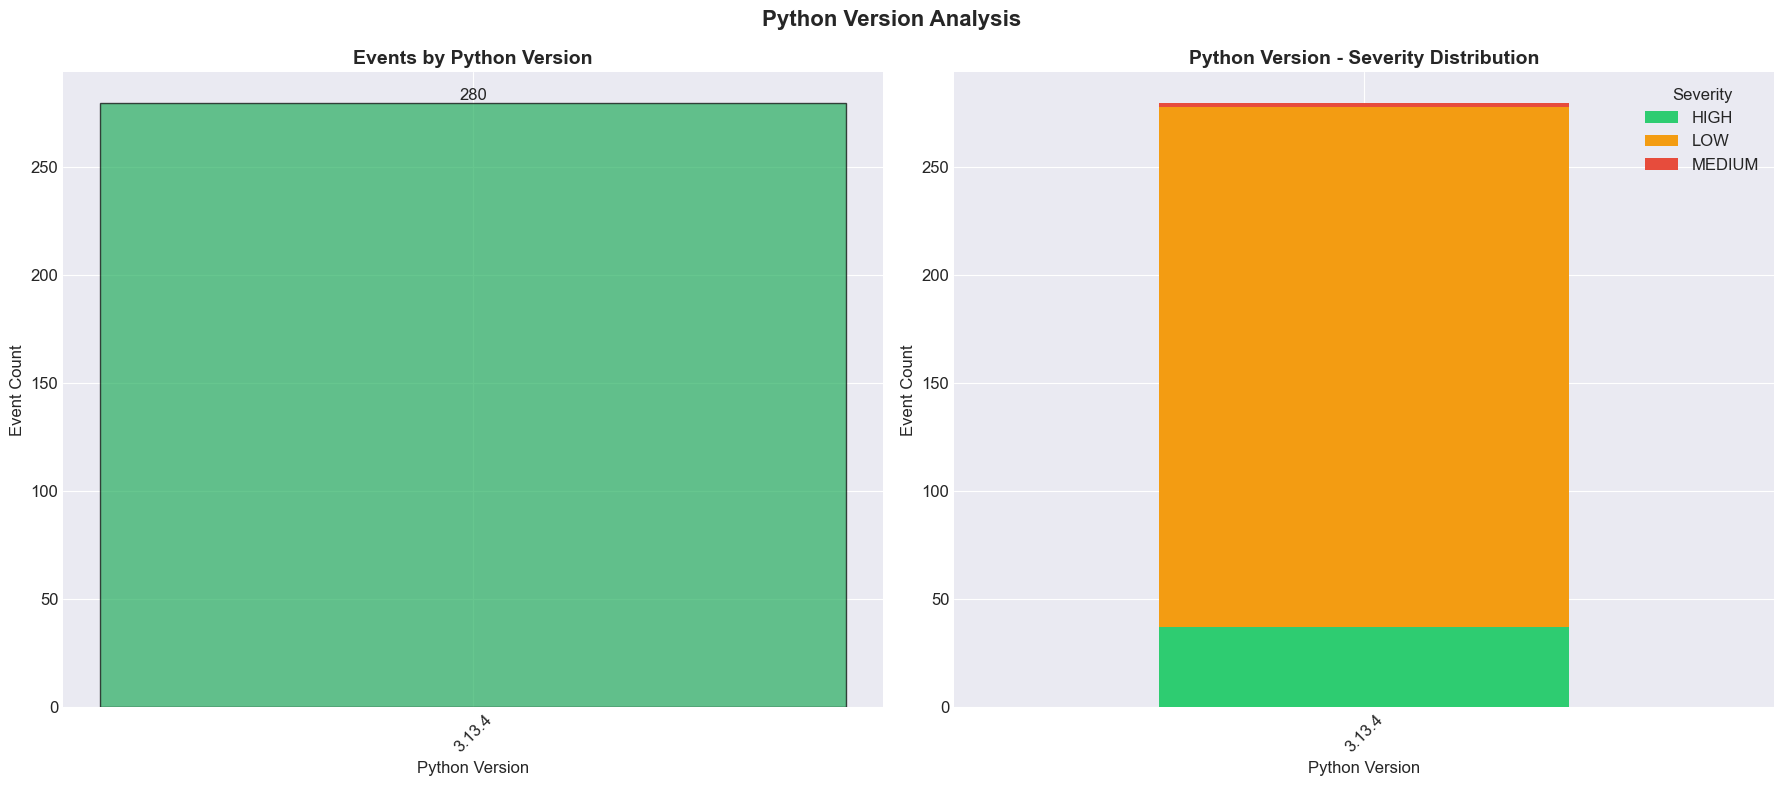

In [17]:
if not df.empty and 'python_version' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle('Python Version Analysis', fontsize=16, fontweight='bold')
    
    # Python version distribution
    ax1 = axes[0]
    python_counts = df['python_version'].value_counts().sort_index()
    bars1 = ax1.bar(python_counts.index.astype(str), python_counts.values, 
                    color='#27ae60', alpha=0.7, edgecolor='black')
    ax1.set_title('Events by Python Version')
    ax1.set_xlabel('Python Version')
    ax1.set_ylabel('Event Count')
    ax1.tick_params(axis='x', rotation=45)
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')
    
    # Python version by severity
    ax2 = axes[1]
    python_severity = pd.crosstab(df['python_version'], df['severity'])
    python_severity.plot(kind='bar', stacked=True, ax=ax2,
                        color=['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad'])
    ax2.set_title('Python Version - Severity Distribution')
    ax2.set_xlabel('Python Version')
    ax2.set_ylabel('Event Count')
    ax2.legend(title='Severity')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()


## PART 5: REQUEST ANALYSIS (INCOMING_REQUEST)
## -------------------------------------------

📨 Found 54 INCOMING_REQUEST events


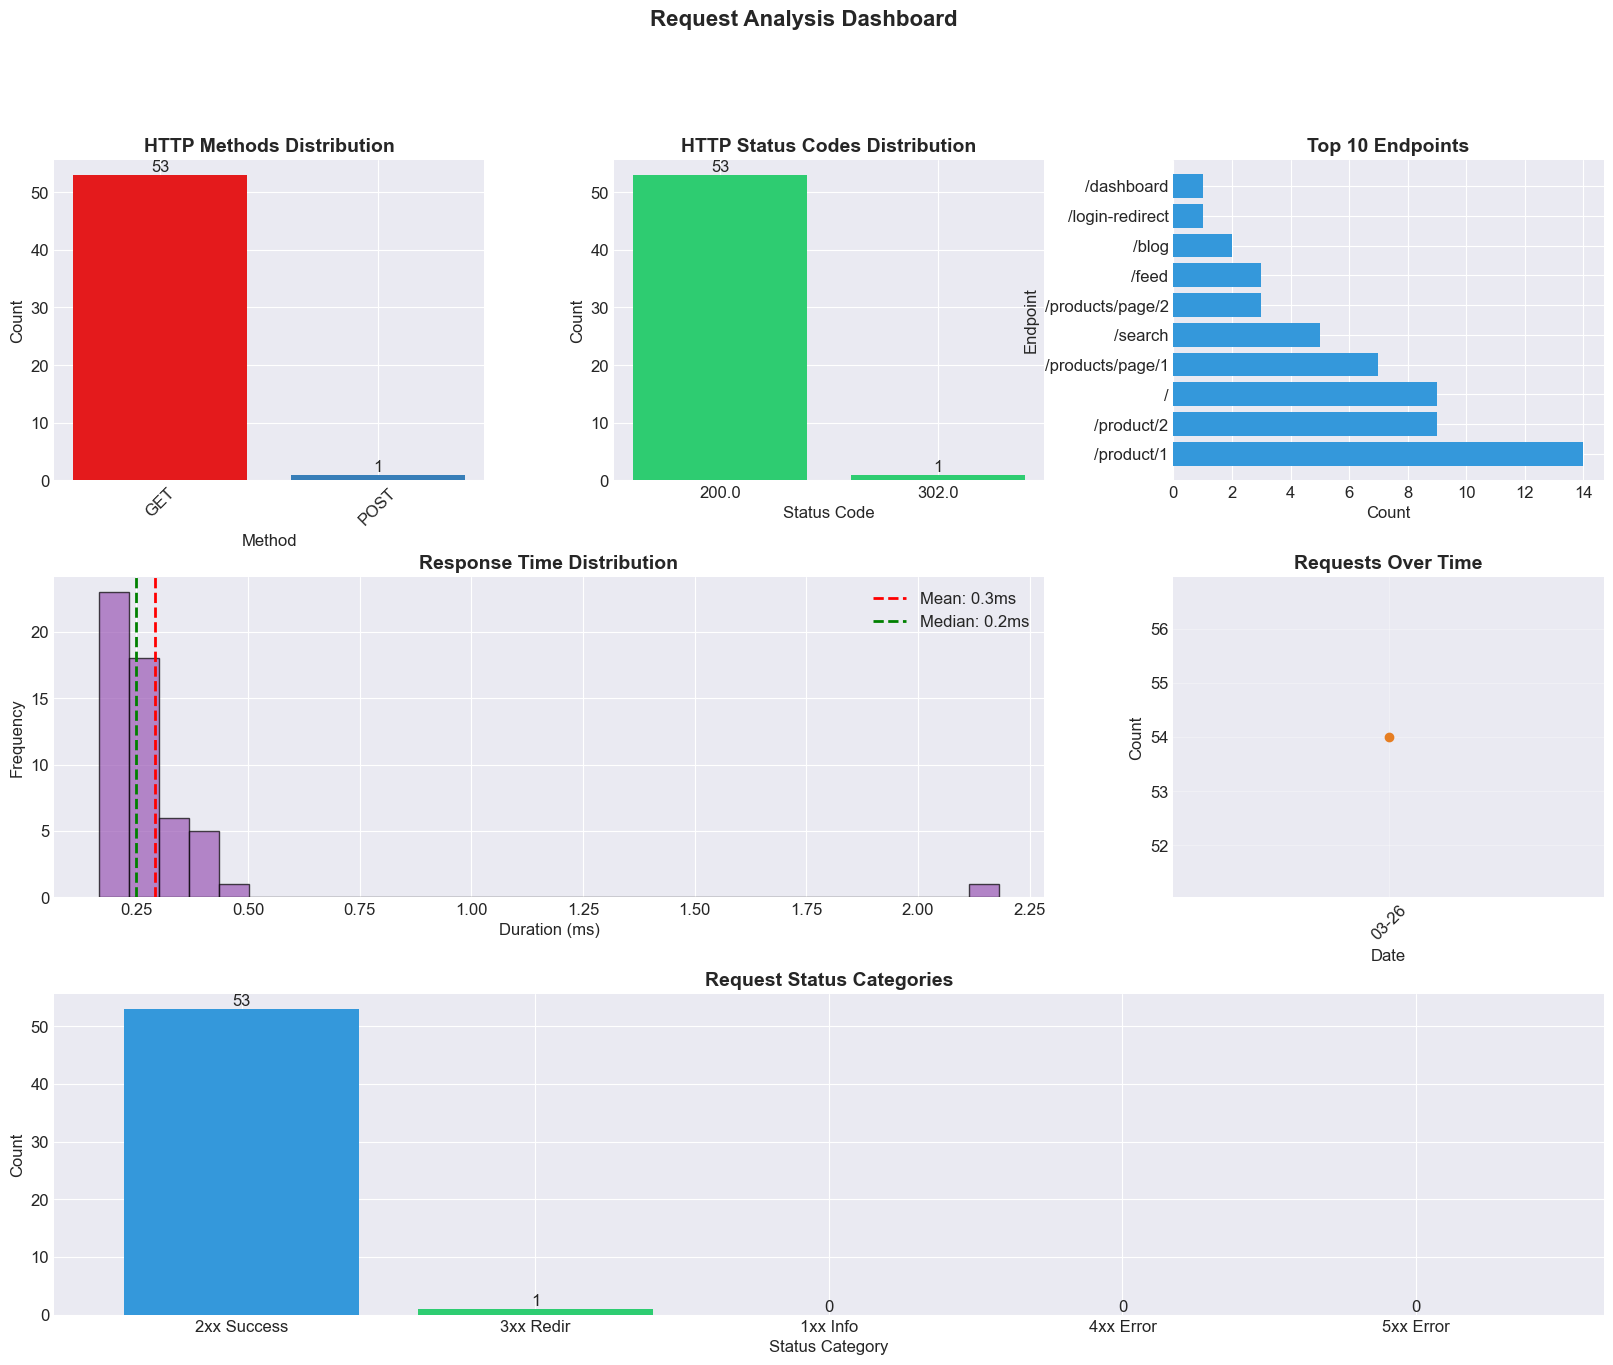


📊 Request Statistics:
   Total Requests: 54
   Average Response Time: 0.29ms
   Success Rate (2xx): 98.1%
   Error Rate (4xx/5xx): 0.0%


In [18]:
# Filter for request events
request_events = df[df['event_type'] == 'INCOMING_REQUEST'].copy() if not df.empty else pd.DataFrame()

if len(request_events) > 0:
    print(f"📨 Found {len(request_events)} INCOMING_REQUEST events")
    
    fig = plt.figure(figsize=(20, 15))
    fig.suptitle('Request Analysis Dashboard', fontsize=16, fontweight='bold')
    
    # 2x2 grid
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. HTTP Methods Distribution
    ax1 = fig.add_subplot(gs[0, 0])
    method_counts = request_events['method'].value_counts()
    colors = plt.cm.Set1(range(len(method_counts)))
    bars1 = ax1.bar(method_counts.index, method_counts.values, color=colors)
    ax1.set_title('HTTP Methods Distribution')
    ax1.set_xlabel('Method')
    ax1.set_ylabel('Count')
    ax1.tick_params(axis='x', rotation=45)
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')
    
    # 2. Status Codes Distribution
    ax2 = fig.add_subplot(gs[0, 1])
    status_counts = request_events['status_code'].value_counts().sort_index()
    colors = ['#2ecc71' if s < 400 else '#e74c3c' if s >= 500 else '#f39c12' 
              for s in status_counts.index]
    bars2 = ax2.bar(status_counts.index.astype(str), status_counts.values, color=colors)
    ax2.set_title('HTTP Status Codes Distribution')
    ax2.set_xlabel('Status Code')
    ax2.set_ylabel('Count')
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')
    
    # 3. Top Endpoints
    ax3 = fig.add_subplot(gs[0, 2])
    top_paths = request_events['path'].value_counts().head(10)
    bars3 = ax3.barh(range(len(top_paths)), top_paths.values, color='#3498db')
    ax3.set_title('Top 10 Endpoints')
    ax3.set_xlabel('Count')
    ax3.set_ylabel('Endpoint')
    ax3.set_yticks(range(len(top_paths)))
    ax3.set_yticklabels([p[:30] + '...' if len(p) > 30 else p for p in top_paths.index])
    
    # 4. Response Time Distribution
    ax4 = fig.add_subplot(gs[1, :2])
    if request_events['duration_ms'].notna().any():
        request_events['duration_ms'].hist(bins=30, ax=ax4, edgecolor='black', 
                                           color='#9b59b6', alpha=0.7)
        ax4.set_title('Response Time Distribution')
        ax4.set_xlabel('Duration (ms)')
        ax4.set_ylabel('Frequency')
        ax4.axvline(request_events['duration_ms'].mean(), color='red', 
                   linestyle='--', linewidth=2, label=f"Mean: {request_events['duration_ms'].mean():.1f}ms")
        ax4.axvline(request_events['duration_ms'].median(), color='green', 
                   linestyle='--', linewidth=2, label=f"Median: {request_events['duration_ms'].median():.1f}ms")
        ax4.legend()
    else:
        ax4.text(0.5, 0.5, 'No duration data available', 
                ha='center', va='center', transform=ax4.transAxes)
    
    # 5. Requests Over Time
    ax5 = fig.add_subplot(gs[1, 2])
    request_time = request_events.groupby(request_events['timestamp'].dt.date).size()
    ax5.plot(range(len(request_time)), request_time.values, 
             marker='o', linewidth=2, color='#e67e22')
    ax5.set_title('Requests Over Time')
    ax5.set_xlabel('Date')
    ax5.set_ylabel('Count')
    ax5.set_xticks(range(0, len(request_time), max(1, len(request_time)//5)))
    ax5.set_xticklabels([str(d)[5:] for d in request_time.index[::max(1, len(request_time)//5)]], 
                        rotation=45)
    ax5.grid(True, alpha=0.3)
    
    # 6. Success vs Error Rate
    ax6 = fig.add_subplot(gs[2, :])
    status_categories = pd.cut(request_events['status_code'], 
                               bins=[0, 199, 299, 399, 499, 599],
                               labels=['1xx Info', '2xx Success', '3xx Redir', '4xx Error', '5xx Error'])
    status_dist = status_categories.value_counts()
    colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#c0392b']
    bars6 = ax6.bar(status_dist.index, status_dist.values, color=colors)
    ax6.set_title('Request Status Categories')
    ax6.set_xlabel('Status Category')
    ax6.set_ylabel('Count')
    for bar in bars6:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Print request statistics
    print("\n📊 Request Statistics:")
    print(f"   Total Requests: {len(request_events)}")
    print(f"   Average Response Time: {request_events['duration_ms'].mean():.2f}ms")
    print(f"   Success Rate (2xx): {(request_events['status_code'] < 300).sum() / len(request_events) * 100:.1f}%")
    print(f"   Error Rate (4xx/5xx): {(request_events['status_code'] >= 400).sum() / len(request_events) * 100:.1f}%")

else:
    print("📨 No INCOMING_REQUEST events found in the data")


## PART 6: ERROR LOG ANALYSIS
## -------------------------

⚠️ Found 33 ERROR logs


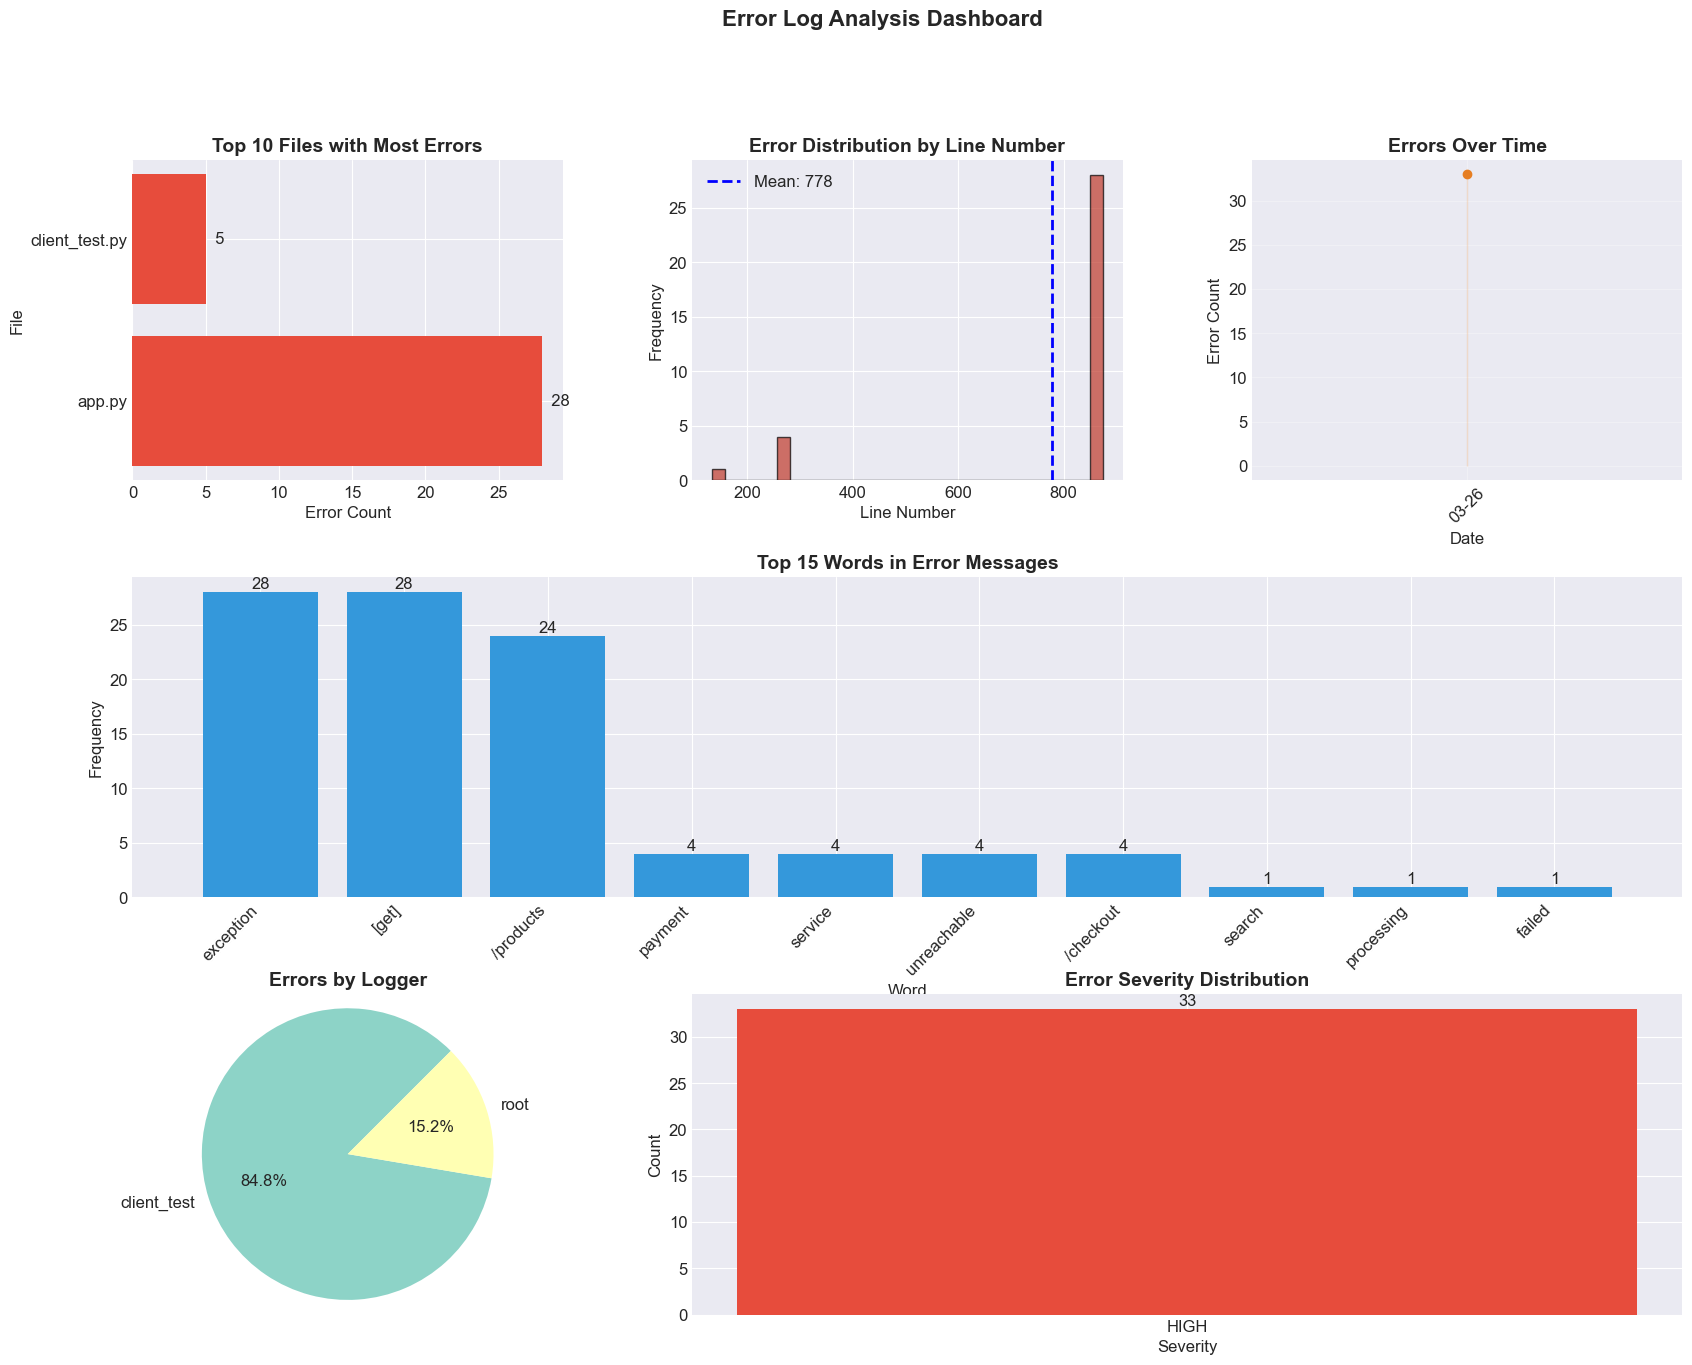


📝 Sample Error Messages:
--------------------------------------------------
1. Exception on /products [GET]
2. Exception on /products [GET]
3. Exception on /products [GET]
4. Payment service unreachable
5. Exception on /products [GET]


In [19]:
# Filter for error logs
error_logs = df[(df['event_type'] == 'LOG')].copy() if not df.empty else pd.DataFrame()
error_logs_high = error_logs[error_logs['level'] == 'ERROR'] if not error_logs.empty else pd.DataFrame()

if len(error_logs_high) > 0:
    print(f"⚠️ Found {len(error_logs_high)} ERROR logs")
    
    fig = plt.figure(figsize=(20, 15))
    fig.suptitle('Error Log Analysis Dashboard', fontsize=16, fontweight='bold')
    
    # 2x2 grid with one span
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. Errors by File
    ax1 = fig.add_subplot(gs[0, 0])
    file_errors = error_logs_high['file'].value_counts().head(10)
    bars1 = ax1.barh(range(len(file_errors)), file_errors.values, color='#e74c3c')
    ax1.set_title('Top 10 Files with Most Errors')
    ax1.set_xlabel('Error Count')
    ax1.set_ylabel('File')
    ax1.set_yticks(range(len(file_errors)))
    ax1.set_yticklabels([f.split('\\')[-1] if '\\' in f else f.split('/')[-1] 
                         for f in file_errors.index])
    for i, (bar, count) in enumerate(zip(bars1, file_errors.values)):
        ax1.text(count, i, f'  {count}', va='center')
    
    # 2. Errors by Line Number
    ax2 = fig.add_subplot(gs[0, 1])
    if error_logs_high['line'].notna().any():
        error_logs_high['line'].hist(bins=30, ax=ax2, edgecolor='black', 
                                      color='#c0392b', alpha=0.7)
        ax2.set_title('Error Distribution by Line Number')
        ax2.set_xlabel('Line Number')
        ax2.set_ylabel('Frequency')
        ax2.axvline(error_logs_high['line'].mean(), color='blue', 
                   linestyle='--', linewidth=2, label=f"Mean: {error_logs_high['line'].mean():.0f}")
        ax2.legend()
    else:
        ax2.text(0.5, 0.5, 'No line number data available', 
                ha='center', va='center', transform=ax2.transAxes)
    
    # 3. Error Timeline
    ax3 = fig.add_subplot(gs[0, 2])
    error_time = error_logs_high.groupby(error_logs_high['timestamp'].dt.date).size()
    ax3.plot(range(len(error_time)), error_time.values, 
             marker='o', linewidth=2, color='#e67e22', markersize=6)
    ax3.fill_between(range(len(error_time)), error_time.values, alpha=0.2, color='#e67e22')
    ax3.set_title('Errors Over Time')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Error Count')
    ax3.set_xticks(range(0, len(error_time), max(1, len(error_time)//5)))
    ax3.set_xticklabels([str(d)[5:] for d in error_time.index[::max(1, len(error_time)//5)]], 
                        rotation=45)
    ax3.grid(True, alpha=0.3)
    
    # 4. Error Messages Analysis
    ax4 = fig.add_subplot(gs[1, :])
    if error_logs_high['message'].notna().any():
        # Get common words in error messages
        all_messages = ' '.join(error_logs_high['message'].dropna().astype(str))
        # Simple word frequency (excluding common words)
        common_words = ['the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
                       'of', 'with', 'by', 'from', 'as', 'is', 'was', 'are', 'were']
        words = [w.lower() for w in all_messages.split() 
                if w.lower() not in common_words and len(w) > 2]
        word_freq = pd.Series(words).value_counts().head(15)
        
        bars4 = ax4.bar(range(len(word_freq)), word_freq.values, color='#3498db')
        ax4.set_title('Top 15 Words in Error Messages')
        ax4.set_xlabel('Word')
        ax4.set_ylabel('Frequency')
        ax4.set_xticks(range(len(word_freq)))
        ax4.set_xticklabels(word_freq.index, rotation=45, ha='right')
        for bar in bars4:
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom')
    else:
        ax4.text(0.5, 0.5, 'No error messages available', 
                ha='center', va='center', transform=ax4.transAxes)
    
    # 5. Logger Distribution
    ax5 = fig.add_subplot(gs[2, 0])
    logger_counts = error_logs_high['logger_name'].value_counts()
    colors = plt.cm.Set3(range(len(logger_counts)))
    wedges, texts, autotexts = ax5.pie(logger_counts.values, 
                                        labels=logger_counts.index,
                                        autopct='%1.1f%%',
                                        colors=colors,
                                        startangle=45)
    ax5.set_title('Errors by Logger')
    ax5.axis('equal')
    
    # 6. Error Severity Breakdown
    ax6 = fig.add_subplot(gs[2, 1:])
    error_severity = error_logs_high['severity'].value_counts()
    colors = {'LOW': '#2ecc71', 'MEDIUM': '#f39c12', 'HIGH': '#e74c3c', 'CRITICAL': '#8e44ad'}
    bar_colors = [colors.get(sev, '#3498db') for sev in error_severity.index]
    bars6 = ax6.bar(error_severity.index, error_severity.values, color=bar_colors)
    ax6.set_title('Error Severity Distribution')
    ax6.set_xlabel('Severity')
    ax6.set_ylabel('Count')
    for bar in bars6:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Print sample error messages
    print("\n📝 Sample Error Messages:")
    print("-" * 50)
    for idx, msg in enumerate(error_logs_high['message'].dropna().head(5)):
        print(f"{idx+1}. {msg}")

elif len(error_logs) > 0:
    print(f"📝 Found {len(error_logs)} LOG events, but no ERROR level logs")
else:
    print("📝 No LOG events found in the data")


⚠️ Found 84 FAILURE events


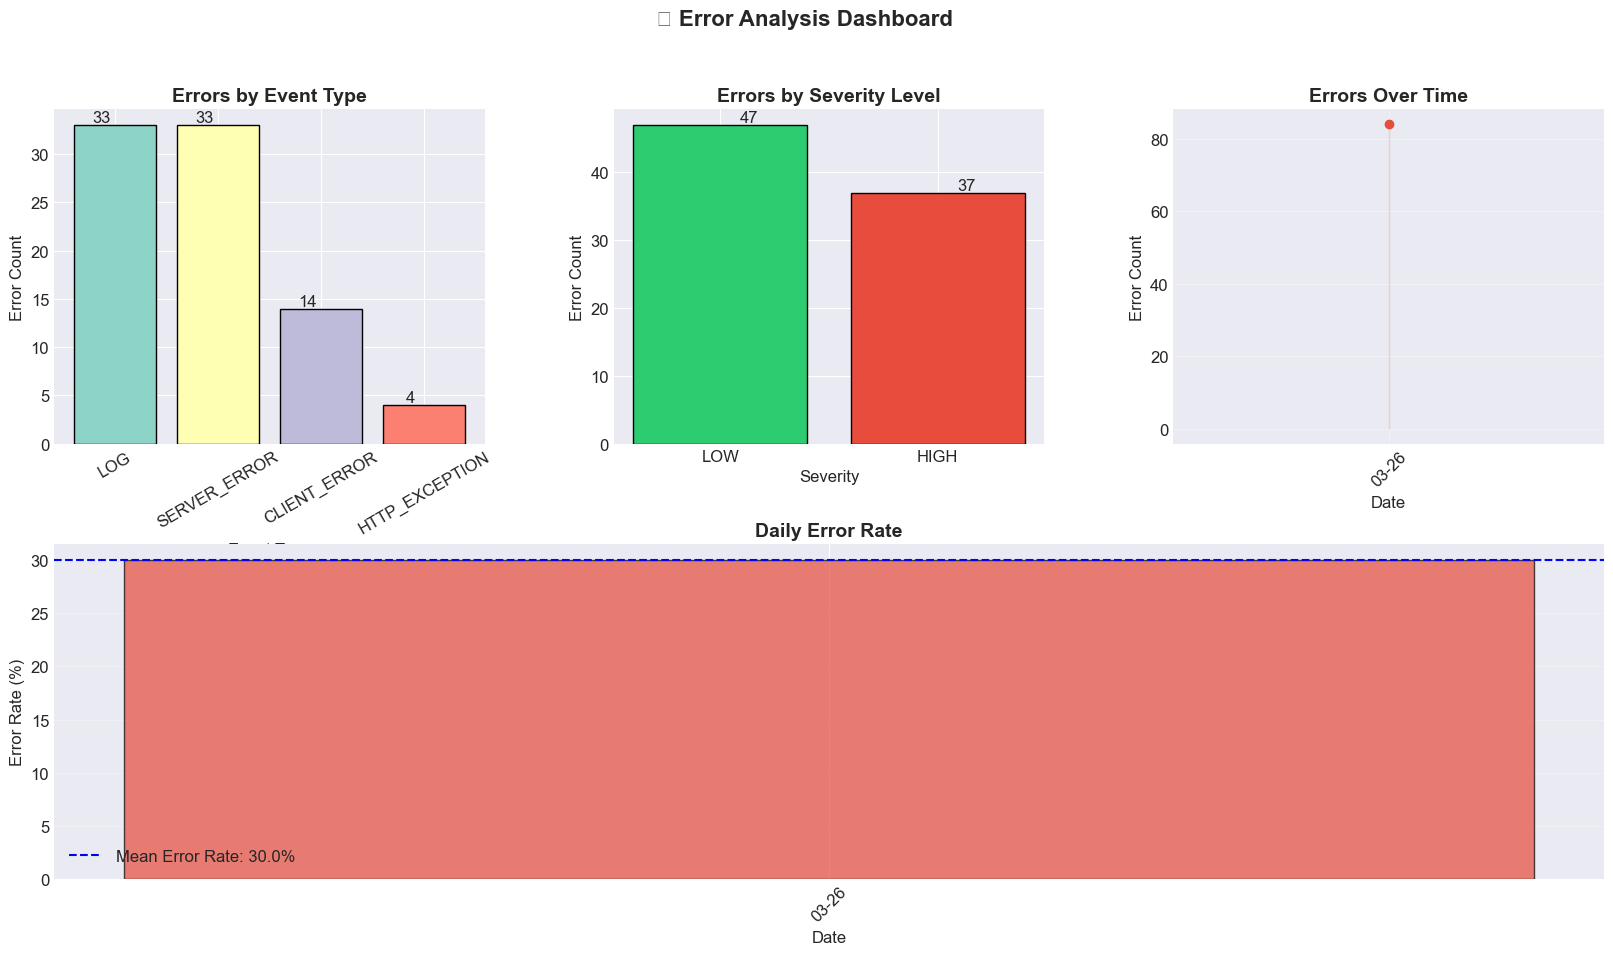


📊 Average Error Rate: 30.00%
📊 Peak Error Rate: 30.00%


In [20]:

# Filter for error events (FAILURE status)
error_events = df[df['status'] == 'FAILURE'].copy()

if len(error_events) > 0:
    print(f"⚠️ Found {len(error_events):,} FAILURE events")
    
    fig = plt.figure(figsize=(20, 10))
    fig.suptitle('❌ Error Analysis Dashboard', fontsize=16, fontweight='bold')
    
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
    
    # 1. Errors by Event Type
    ax1 = fig.add_subplot(gs[0, 0])
    error_types = error_events['event_type'].value_counts()
    colors = plt.cm.Set3(range(len(error_types)))
    bars1 = ax1.bar(error_types.index, error_types.values, color=colors, edgecolor='black')
    ax1.set_title('Errors by Event Type')
    ax1.set_xlabel('Event Type')
    ax1.set_ylabel('Error Count')
    ax1.tick_params(axis='x', rotation=30,)
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/3, height,
                f'{int(height):,}', ha='center', va='bottom')
    
    # 2. Errors by Severity
    ax2 = fig.add_subplot(gs[0, 1])
    error_severity = error_events['severity'].value_counts()
    error_severity = error_severity.reindex([s for s in severity_order if s in error_severity.index])
    colors = [severity_colors.get(sev, '#3498db') for sev in error_severity.index]
    bars2 = ax2.bar(error_severity.index, error_severity.values, color=colors, edgecolor='black')
    ax2.set_title('Errors by Severity Level')
    ax2.set_xlabel('Severity')
    ax2.set_ylabel('Error Count')
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width() * 2/3, height,
                f'{int(height):,}', ha='center', va='bottom')
    
    # 3. Error Timeline
    ax3 = fig.add_subplot(gs[0, 2])
    error_time = error_events.groupby(error_events['timestamp'].dt.date).size()
    ax3.plot(range(len(error_time)), error_time.values, 
             marker='o', linewidth=2, color='#e74c3c', markersize=6)
    ax3.fill_between(range(len(error_time)), error_time.values, alpha=0.2, color='#e74c3c')
    ax3.set_title('Errors Over Time')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Error Count')
    ax3.set_xticks(range(0, len(error_time), max(1, len(error_time)//5)))
    ax3.set_xticklabels([str(d)[5:] for d in error_time.index[::max(1, len(error_time)//5)]], 
                        rotation=45)
    ax3.grid(True, alpha=0.3)
    
    # 4. Error Rate Over Time
    ax4 = fig.add_subplot(gs[1, :])
    daily_total = df.groupby('date').size()
    daily_errors = error_events.groupby(error_events['timestamp'].dt.date).size()
    error_rate = (daily_errors / daily_total * 100).fillna(0)
    
    ax4.bar(range(len(error_rate)), error_rate.values, color='#e74c3c', alpha=0.7, edgecolor='black')
    ax4.set_title('Daily Error Rate')
    ax4.set_xlabel('Date')
    ax4.set_ylabel('Error Rate (%)')
    ax4.set_xticks(range(0, len(error_rate), max(1, len(error_rate)//7)))
    ax4.set_xticklabels([str(d)[5:] for d in error_rate.index[::max(1, len(error_rate)//7)]], 
                        rotation=45)
    ax4.axhline(y=error_rate.mean(), color='blue', linestyle='--', 
                label=f'Mean Error Rate: {error_rate.mean():.1f}%')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 Average Error Rate: {error_rate.mean():.2f}%")
    print(f"📊 Peak Error Rate: {error_rate.max():.2f}%")

else:
    print("✅ No FAILURE events found in the data")


## PART 7: INTERACTIVE VISUALIZATIONS
## ----------------------------------

### 7.1 Interactive Event Distribution

In [21]:
if not df.empty:
    # Create interactive dashboard with Plotly
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=('Event Type Distribution', 'Severity Distribution', 
                       'Status Distribution', 'Events Timeline'),
        specs=[[{'type': 'pie'}, {'type': 'bar'}],
               [{'type': 'bar'}, {'type': 'scatter'}]]
    )
    
    # 1. Event Type Pie Chart
    event_counts = df['event_type'].value_counts()
    fig.add_trace(
        go.Pie(labels=event_counts.index, values=event_counts.values,
               name="Event Types"),
        row=1, col=1
    )
    
    # 2. Severity Bar Chart
    severity_counts = df['severity'].value_counts()
    fig.add_trace(
        go.Bar(x=severity_counts.index, y=severity_counts.values,
               name="Severity", marker_color=['green', 'orange', 'red', 'darkred']),
        row=1, col=2
    )
    
    # 3. Status Bar Chart
    status_counts = df['status'].value_counts()
    fig.add_trace(
        go.Bar(x=status_counts.index, y=status_counts.values,
               name="Status", marker_color=['green', 'red']),
        row=2, col=1
    )
    
    # 4. Timeline
    daily_events = df.groupby('date').size().reset_index()
    daily_events.columns = ['date', 'count']
    fig.add_trace(
        go.Scatter(x=daily_events['date'], y=daily_events['count'],
                  mode='lines+markers', name='Daily Events',
                  line=dict(color='blue', width=2)),
        row=2, col=2
    )
    
    fig.update_layout(height=800, showlegend=False,
                     title_text="Interactive Event Dashboard")
    fig.show()


### 7.2 Interactive Severity Timeline

In [22]:
if not df.empty and 'severity' in df.columns:
    # Severity over time
    severity_time = df.groupby(['date', 'severity']).size().reset_index(name='count')
    
    fig = px.line(severity_time, x='date', y='count', color='severity',
                  title='Events Over Time by Severity',
                  color_discrete_map={'LOW': 'green', 'MEDIUM': 'orange',
                                     'HIGH': 'red', 'CRITICAL': 'darkred'},
                  markers=True)
    fig.update_layout(xaxis_title="Date", yaxis_title="Number of Events")
    fig.show()


### 7.3 Interactive 3D Scatter Plot


In [23]:
if not df.empty:
    # Create numeric columns for 3D visualization
    df['hour'] = df['timestamp'].dt.hour
    df['day'] = df['timestamp'].dt.day
    df['month'] = df['timestamp'].dt.month
    
    # Create 3D scatter plot
    fig = px.scatter_3d(df, x='hour', y='day', z='month',
                        color='severity', symbol='event_type',
                        title='3D Event Distribution (Time-based)',
                        color_discrete_map={'LOW': 'green', 'MEDIUM': 'orange',
                                           'HIGH': 'red', 'CRITICAL': 'darkred'})
    fig.update_layout(scene=dict(xaxis_title='Hour',
                                 yaxis_title='Day',
                                 zaxis_title='Month'))
    fig.show()



## PART 8: SUMMARY DASHBOARD
## -------------------------

### 8.1 Key Metrics Dashboard

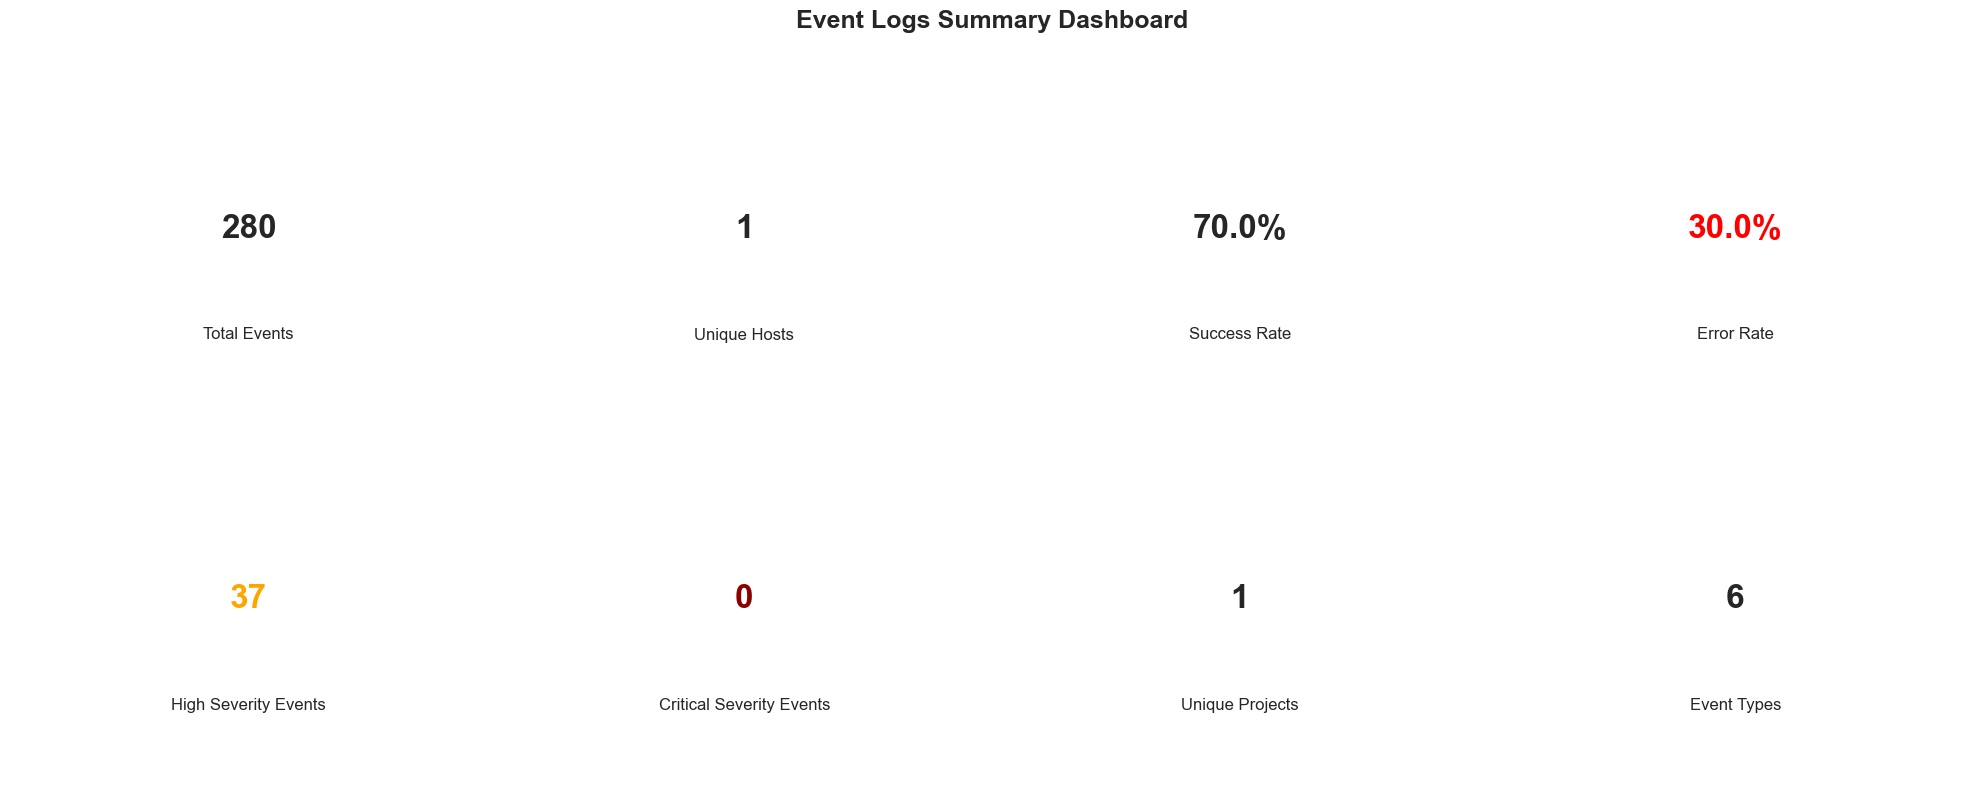

In [24]:
if not df.empty:
    # Calculate key metrics
    total_events = len(df)
    unique_hosts = df['hostname'].nunique()
    unique_projects = df['project'].nunique()
    error_count = len(df[df['status'] == 'FAILURE'])
    success_count = len(df[df['status'] == 'SUCCESS'])
    high_severity = len(df[df['severity'] == 'HIGH'])
    critical_severity = len(df[df['severity'] == 'CRITICAL'])
    
    # Create metrics dashboard
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    fig.suptitle('Event Logs Summary Dashboard', fontsize=18, fontweight='bold')
    
    # Metric 1: Total Events
    axes[0, 0].text(0.5, 0.5, f'{total_events:,}', 
                    ha='center', va='center', fontsize=24, fontweight='bold')
    axes[0, 0].text(0.5, 0.2, 'Total Events', 
                    ha='center', va='center', fontsize=12)
    axes[0, 0].axis('off')
    
    # Metric 2: Unique Hosts
    axes[0, 1].text(0.5, 0.5, f'{unique_hosts}', 
                    ha='center', va='center', fontsize=24, fontweight='bold')
    axes[0, 1].text(0.5, 0.2, 'Unique Hosts', 
                    ha='center', va='center', fontsize=12)
    axes[0, 1].axis('off')
    
    # Metric 3: Success Rate
    success_rate = (success_count / total_events * 100) if total_events > 0 else 0
    axes[0, 2].text(0.5, 0.5, f'{success_rate:.1f}%', 
                    ha='center', va='center', fontsize=24, fontweight='bold')
    axes[0, 2].text(0.5, 0.2, 'Success Rate', 
                    ha='center', va='center', fontsize=12)
    axes[0, 2].axis('off')
    
    # Metric 4: Error Rate
    error_rate = (error_count / total_events * 100) if total_events > 0 else 0
    axes[0, 3].text(0.5, 0.5, f'{error_rate:.1f}%', 
                    ha='center', va='center', fontsize=24, fontweight='bold', color='red')
    axes[0, 3].text(0.5, 0.2, 'Error Rate', 
                    ha='center', va='center', fontsize=12)
    axes[0, 3].axis('off')
    
    # Metric 5: High Severity
    axes[1, 0].text(0.5, 0.5, f'{high_severity}', 
                    ha='center', va='center', fontsize=24, fontweight='bold', color='orange')
    axes[1, 0].text(0.5, 0.2, 'High Severity Events', 
                    ha='center', va='center', fontsize=12)
    axes[1, 0].axis('off')
    
    # Metric 6: Critical Severity
    axes[1, 1].text(0.5, 0.5, f'{critical_severity}', 
                    ha='center', va='center', fontsize=24, fontweight='bold', color='darkred')
    axes[1, 1].text(0.5, 0.2, 'Critical Severity Events', 
                    ha='center', va='center', fontsize=12)
    axes[1, 1].axis('off')
    
    # Metric 7: Unique Projects
    axes[1, 2].text(0.5, 0.5, f'{unique_projects}', 
                    ha='center', va='center', fontsize=24, fontweight='bold')
    axes[1, 2].text(0.5, 0.2, 'Unique Projects', 
                    ha='center', va='center', fontsize=12)
    axes[1, 2].axis('off')
    
    # Metric 8: Event Types
    event_types_count = df['event_type'].nunique()
    axes[1, 3].text(0.5, 0.5, f'{event_types_count}', 
                    ha='center', va='center', fontsize=24, fontweight='bold')
    axes[1, 3].text(0.5, 0.2, 'Event Types', 
                    ha='center', va='center', fontsize=12)
    axes[1, 3].axis('off')
    
    plt.tight_layout()
    plt.show()


 ### 8.2 Final Summary and Insights

In [25]:
if not df.empty:
    print("=" * 60)
    print("FINAL SUMMARY AND INSIGHTS")
    print("=" * 60)
    
    # Overall statistics
    print(f"\n📊 OVERALL STATISTICS:")
    print(f"   • Total Events Analyzed: {len(df)}")
    print(f"   • Time Period: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
    print(f"   • Total Duration: {(df['timestamp'].max() - df['timestamp'].min()).days} days")
    
    # Event composition
    print(f"\n📊 EVENT COMPOSITION:")
    for event_type in df['event_type'].unique():
        count = len(df[df['event_type'] == event_type])
        pct = count / len(df) * 100
        print(f"   • {event_type}: {count} ({pct:.1f}%)")
    
    # Health metrics
    print(f"\n📊 SYSTEM HEALTH:")
    print(f"   • Success Rate: {success_rate:.1f}%")
    print(f"   • Error Rate: {error_rate:.1f}%")
    print(f"   • High/Critical Severity: {high_severity + critical_severity} ({(high_severity + critical_severity)/len(df)*100:.1f}%)")
    
    # Infrastructure
    print(f"\n📊 INFRASTRUCTURE:")
    print(f"   • Active Hosts: {unique_hosts}")
    print(f"   • Operating Systems: {df['os'].nunique()}")
    print(f"   • Python Versions: {df['python_version'].nunique()}")
    
    # Top findings
    print(f"\n🔍 TOP FINDINGS:")
    print(f"   • Most Active Host: {df['hostname'].mode()[0]}")
    print(f"   • Peak Hour: {df.groupby('hour').size().idxmax()}:00")
    print(f"   • Most Common Event: {df['event_type'].mode()[0]}")
    
    # Recommendations based on findings
    print(f"\n💡 RECOMMENDATIONS:")
    if error_rate > 10:
        print("   • ⚠️ High error rate detected - Investigate failure patterns")
    if high_severity > 10:
        print("   • ⚠️ Many high severity events - Prioritize error fixing")
    if success_rate < 90:
        print("   • ⚠️ Success rate below 90% - Review system stability")
    if error_rate <= 10 and success_rate >= 90:
        print("   • ✅ System appears healthy - Continue monitoring")
    
    print("\n" + "=" * 60)
    print("END OF ANALYSIS")
    print("=" * 60)


FINAL SUMMARY AND INSIGHTS

📊 OVERALL STATISTICS:
   • Total Events Analyzed: 280
   • Time Period: 2026-03-26 to 2026-03-26
   • Total Duration: 0 days

📊 EVENT COMPOSITION:
   • SPAN: 140 (50.0%)
   • INCOMING_REQUEST: 54 (19.3%)
   • LOG: 35 (12.5%)
   • SERVER_ERROR: 33 (11.8%)
   • HTTP_EXCEPTION: 4 (1.4%)
   • CLIENT_ERROR: 14 (5.0%)

📊 SYSTEM HEALTH:
   • Success Rate: 70.0%
   • Error Rate: 30.0%
   • High/Critical Severity: 37 (13.2%)

📊 INFRASTRUCTURE:
   • Active Hosts: 1
   • Operating Systems: 1
   • Python Versions: 1

🔍 TOP FINDINGS:
   • Most Active Host: DESKTOP-N00M686
   • Peak Hour: 19:00
   • Most Common Event: SPAN

💡 RECOMMENDATIONS:
   • ⚠️ High error rate detected - Investigate failure patterns
   • ⚠️ Many high severity events - Prioritize error fixing
   • ⚠️ Success rate below 90% - Review system stability

END OF ANALYSIS


 ### 8.3 Export Processed Data

In [26]:
if not df.empty:
    # Export to CSV
    output_file = 'processed_events_analysis.csv'
    df.to_csv(output_file, index=False)
    print(f"✅ Processed data exported to: {output_file}")
    
    # Export summary statistics
    summary_stats = {
        'total_events': len(df),
        'unique_hosts': unique_hosts,
        'unique_projects': unique_projects,
        'success_rate': f"{success_rate:.2f}%",
        'error_rate': f"{error_rate:.2f}%",
        'high_severity_count': high_severity,
        'critical_severity_count': critical_severity,
        'date_range_start': str(df['timestamp'].min()),
        'date_range_end': str(df['timestamp'].max()),
        'most_active_host': df['hostname'].mode()[0],
        'peak_hour': int(df.groupby('hour').size().idxmax())
    }
    
    summary_file = 'analysis_summary.json'
    with open(summary_file, 'w') as f:
        json.dump(summary_stats, f, indent=2)
    print(f"✅ Summary statistics exported to: {summary_file}")



✅ Processed data exported to: processed_events_analysis.csv
✅ Summary statistics exported to: analysis_summary.json


## END OF NOTEBOOK
## ===============
